In [1]:


from __future__ import print_function, division

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torch.backends.cudnn as cudnn
import numpy as np
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import time
import os
import copy
from glob import glob
import pandas as pd
from PIL import Image
import torchdata.datapipes as dp
import random
from torch.utils.data.backward_compatibility import worker_init_fn
from sklearn.metrics import classification_report
import wandb
import plotly.graph_objects as go

cudnn.benchmark = True
plt.ion()   # interactive mode


In [2]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_recall_fscore_support
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import precision_recall_curve
import plotly.graph_objects as go
from sklearn.metrics import confusion_matrix

## Split Data (Patient-wise)

In [ ]:
annotation_df = pd.read_csv("WM_Annotations_with_augmented_counts.csv")

In [ ]:
def map_tag(filename):
    if filename.startswith("PD"):
        return "PDD"
    else:
        return "DLB"
annotation_df["LBD_tag"]=annotation_df["filename"].apply(lambda l : map_tag(l))
annotation_df = annotation_df.sort_values(by="filename").reset_index()
annotation_df["index"]=annotation_df.index

In [ ]:
random_list = random.sample(range(0, 31), 20)
annotation_df["train_test_flag"]=np.where(annotation_df["index"].isin(random_list),"Train","Val")
annotation_df.groupby(["train_test_flag","LBD_tag"])["filename"].count()

In [ ]:
annotation_df

In [ ]:
annotation_df.to_csv("WM_Annotations_with_augmented_counts.csv")

## Create a dataframe/csv data containing all image paths and labels

In [ ]:
annotation_df = pd.read_csv("WM_Annotations_with_augmented_counts.csv")

In [ ]:
def map_label(class_name):
    if class_name=="White":
        return 0
    if class_name=="grey":
        return 1
    if class_name=="bg":
        return 2
    return -1

def create_df_from_folders(train_test_flag):
    patient_df = annotation_df[annotation_df["train_test_flag"]==train_test_flag]
    data_dir =  "/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/WM_images/"
    df = pd.DataFrame(columns=["WSI_filename","crop_filepath","class"])
    ind = 0
    for index in patient_df.index:
        folder_name = annotation_df.iloc[index]["filename"].replace(".geojson","")
        for label_name in ["White","grey","bg"]:
            files = glob(os.path.join(data_dir, folder_name, label_name, '*.png'))
            #print(len(files))
            temp_df =  pd.DataFrame({"crop_filepath":files})
            temp_df["WSI_filename"] = folder_name
            temp_df["class"] = label_name
            df = pd.concat([df, temp_df], ignore_index=True)
    df["label"]=df["class"].apply(lambda l:map_label(l))
    return df

train_df = create_df_from_folders("Train")
val_df = create_df_from_folders("Val")
#test_df = create_df_from_folders("Test")

print("Training Data Size :", len(train_df))
print("Validation Data Size :", len(val_df))
#print("Test Data Size : ", len(test_df))

In [ ]:
train_df.to_csv("train_full.csv")
val_df.to_csv("val_full.csv")

In [ ]:
train_df[["WSI_filename","crop_filepath","label"]].to_csv("train.csv")
val_df[["WSI_filename","crop_filepath","label"]].to_csv("val.csv")

In [ ]:
train_df["WSI_filename"].unique()

In [ ]:
val_df["WSI_filename"].unique()

In [ ]:
train1 = train_df[train_df["WSI_filename"].isin(['11_063_CG_aSyn_x200.svs', '12_007_CG_aSyn_x200.svs','PD002_Syn1_CG.svs', 'PD013_Syn1_CG.svs'])]
val1=val_df[val_df["WSI_filename"].isin(['13_177_CG_aSyn_x200.svs','PD034_Syn1_CG.svs'])]
train1[["WSI_filename","crop_filepath","label"]].to_csv("train1.csv")
val1[["WSI_filename","crop_filepath","label"]].to_csv("val1.csv")
print(len(train1))
print(len(val1))

## Build Torch Dataset

In [3]:
batch_size = 16

In [4]:
# Data augmentation and normalization for training
# Just normalization for validation
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize(1024),
        #transforms.RandomHorizontalFlip(),
        #transforms.RandomVerticalFlip(),
        #transforms.FiveCrop(256),
        transforms.ToTensor(),
        transforms.Normalize([0.8478, 0.8328, 0.8679], [0.0932, 0.0973, 0.0825])
    ]),
    'val': transforms.Compose([
        transforms.Resize(1024),
        #transforms.CenterCrop(256),
        transforms.ToTensor(),
        transforms.Normalize([0.8478, 0.8328, 0.8679], [0.0932, 0.0973, 0.0825])
    ]),
    'test': transforms.Compose([
        transforms.Resize(1024),
        #transforms.CenterCrop(256),
        transforms.ToTensor(),
        transforms.Normalize([0.8478, 0.8328, 0.8679], [0.0932, 0.0973, 0.0825])
    ]),
}


In [5]:
def open_image(inputs):
    _ , wsi_name, img_path, label = inputs
    img = Image.open(img_path)
    return wsi_name, img, int(label)

def apply_train_transforms(inputs):
    _, x, y = inputs
    return data_transforms["train"](x), y

def apply_val_transforms(inputs):
    wsi_name, x, y = inputs
    return wsi_name, data_transforms["val"](x), y

def build_data_pipe(csv_file, transform , batch_size=32):
    new_dp = dp.iter.FileOpener([csv_file])
    new_dp = new_dp.parse_csv(skip_lines=1)
    # returns tuples like ('0','filename', 'filepath', 'label')
    if transform == "train":
        new_dp = new_dp.shuffle()
    
        new_dp = new_dp.sharding_filter()
    # important to use sharding_filter after (not before) shuffling -For the data source that needs to be sharded, it is crucial to add Shuffler before ShardingFilter to ensure data are globally shuffled before being split into shards. Otherwise, each worker process would always process the same shard of data for all epochs. And, it means each batch would only consist of data from the same shard, which leads to low accuracy during training. However, it doesn’t apply to the data source that has already been sharded for each multi-/distributed process, since ShardingFilter is no longer required to be presented in the pipeline.

    new_dp = new_dp.map(open_image)

    if transform == "train":
        new_dp = new_dp.map(apply_train_transforms)
        new_dp = new_dp.batch(batch_size=batch_size, drop_last=True)

    elif transform == "val":
        new_dp = new_dp.map(apply_val_transforms)
        new_dp = new_dp.batch(batch_size=batch_size, drop_last=False)

    else:
        raise ValueError("Invalid transform argument.")

    new_dp = new_dp.map(torch.utils.data.default_collate)
    return new_dp

In [6]:
TRAIN_CSV = "/gladstone/finkbeiner/steve//work/data/npsad_data/monika/LBD/Intermediate_data/train.csv"
VAL_CSV = "/gladstone/finkbeiner/steve//work/data/npsad_data/monika/LBD/Intermediate_data/val.csv"

In [7]:
train_dp = build_data_pipe(TRAIN_CSV, "train", batch_size)
val_dp = build_data_pipe(VAL_CSV, "val", batch_size)

In [8]:
#train_dp = build_data_pipe("train1.csv", "train", batch_size)
#val_dp = build_data_pipe("val1.csv", "val", batch_size)

In [8]:
def dataset_size(csv_file):
    df = pd.read_csv(csv_file)
    return len(df)

train_datasize = dataset_size(TRAIN_CSV)
val_datasize = dataset_size(VAL_CSV)

In [9]:
dataset_sizes = {'train':train_datasize, 'val':val_datasize}

In [10]:
dataset_sizes

{'train': 155698, 'val': 83219}

In [11]:
train_loader = torch.utils.data.DataLoader(
    dataset=train_dp, shuffle=True, num_workers=4)

val_loader = torch.utils.data.DataLoader(
    dataset=val_dp, shuffle=False, num_workers=4)

dataloaders = {"train":train_loader, "val": val_loader}

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

torch.Size([16, 3, 1024, 1024])
tensor([[0, 2, 1, 0, 2, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0]])
torch.Size([3, 2054, 8210])
torch.Size([3, 2054, 8210])
(2054, 8210, 3)


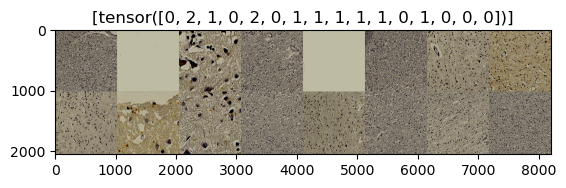

In [12]:
def imshow(inp, title=None):
    """Imshow for Tensor."""
    inp = inp.squeeze()
    print(inp.shape)
    #inp = inp.numpy().transpose((0, 3, 2, 1))
    inp = inp.numpy().transpose((1, 2, 0))
    
    print(inp.shape)
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)  # pause a bit so that plots are updated


# Get a batch of training data
inputs, classes = next(iter(dataloaders['train']))
inputs = inputs.squeeze()
print(inputs.shape)
print(classes)

# Make a grid from batch
out = torchvision.utils.make_grid(inputs)
print(out.shape)
imshow(out, title=[x for x in classes])

## Train Model

In [13]:
train_config = dict(
    epochs = 1,
    batch_size = batch_size,
    num_classes = 3,
    device_id = 0,
    eval_freq = 5,
)

test_config = dict(
    batch_size = 32
)

model_config = dict(lr=0.001, momentum=0.9)

optim_config = dict(step_size=7, gamma=0.1)


wandb_config = dict(
    project='LBD',
    entity='monika-ahirwar',
    config=dict(
        train_config=train_config,
        model_config=model_config,
        optim_config=optim_config,
    ),
    save_code=False,
    group='runs',
    job_type='train',
)
run = wandb.init(**wandb_config)
assert run is wandb.run # run was successfully initialized, is not None
run_id, run_dir = run.id, run.dir
exp_name = run.name
artifact_name = f'{run_id}-logs'
eval_path = "/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/WM_Evaluation_Metrics/"+run_id
WANDB_NOTEBOOK_NAME = "WM_Classification_2.ipynb"


Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Currently logged in as: monika-ahirwar. Use `wandb login --relogin` to force relogin


In [14]:
def plot_roc_auc_curve(run, actual_labels, y_scores, classes, wsi_name):
    y_onehot = pd.get_dummies(actual_labels, columns=classes)
    y_scores = pd.DataFrame(y_scores)
    for i, c in enumerate(classes):
        y_scores[c]=y_scores["scores"].apply(lambda l: l[i])
    y_scores.drop(["scores"], axis=1,inplace=True)
    
    table = wandb.Table(columns = [wsi_name])
    fig = go.Figure()
    fig.add_shape(
        type='line', line=dict(dash='dash'),
        x0=0, x1=1, y0=0, y1=1
    )

    for i in range(len(classes)):
        y_true = y_onehot.iloc[:, i]
        y_score = y_scores.iloc[:, i]

        fpr, tpr, _ = roc_curve(y_true, y_score)
        auc_score = roc_auc_score(y_true, y_score)

        name = f"{y_onehot.columns[i]} (AUC={auc_score:.2f})"
        fig.add_trace(go.Scatter(x=fpr, y=tpr, name=name, mode='lines'))

    fig.update_layout(
        xaxis_title='False Positive Rate',
        yaxis_title='True Positive Rate',
        yaxis=dict(scaleanchor="x", scaleratio=1),
        xaxis=dict(constrain='domain'),
        width=700, height=500
    )
    fig.write_html("/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/WM_Evaluation_Metrics/ROC_Curve_" + wsi_name +".html", auto_play = False)
    table.add_data(wandb.Html("/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/WM_Evaluation_Metrics/ROC_Curve_"+ wsi_name +".html"))
    run.log({"ROC Curve": table})



def plot_pr_curve(run, actual_labels, y_scores, classes, wsi_name):
    table = wandb.Table(columns = [wsi_name])
    y_onehot = pd.get_dummies(actual_labels, columns=classes)
    y_scores = pd.DataFrame(y_scores)
    for i, c in enumerate(classes):
        y_scores[c]=y_scores["scores"].apply(lambda l: l[i])
    y_scores.drop(["scores"], axis=1,inplace=True)
    
    table = wandb.Table(columns = [wsi_name])
    fig = go.Figure()
    for i in range(len(classes)):
        y_true = y_onehot.iloc[:, i]
        y_score = y_scores.iloc[:, i]
        precision, recall, thresholds = precision_recall_curve(y_true, y_score) 
        fig.add_trace(go.Scatter(x=recall, y=precision, name=wsi_name, mode='lines'))
    fig.update_layout(
        xaxis_title='Recall',
        yaxis_title='Precision',
        yaxis=dict(scaleanchor="x", scaleratio=1),
        xaxis=dict(constrain='domain'),
        width=700, height=500
    )

    fig.write_html("/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/WM_Evaluation_Metrics/PR_Curve_" + wsi_name +".html", auto_play = False)
    table.add_data(wandb.Html("/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/WM_Evaluation_Metrics/PR_Curve_"+ wsi_name +".html"))
    run.log({"PR Curve": table})



def plot_training_curve(log_metrics):
    # Create traces
    log_metrics = pd.DataFrame(log_metrics)
    
    for metric in ["loss","metrics"]:
        fig = go.Figure()
        fig.add_trace(go.Scatter(x=log_metrics["epoch"], y=log_metrics[metric],
                            mode='lines+markers',
                            name='Training loss'))
        fig.update_layout(title='Training loss vs Epoch',
                        xaxis_title='Epoch No',
                        yaxis_title='Training Loss')

        fig.write_html("/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/WM_Evaluation_Metrics/Training_Loss.html")

        if metric=="epoch_loss":
            table = wandb.Html("/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/WM_Evaluation_Metrics/Training_Loss.html")
            wandb.log({"Training Loss":table})
        else:
            table = wandb.Html("/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/WM_Evaluation_Metrics/Training_Accuracy.html")
            wandb.log({"Training Accuracy":table})



In [20]:
def train_model(run, model, criterion, optimizer, scheduler, num_epochs=25):
    since = time.time()

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    log_metrics = list()

    for epoch in range(num_epochs):
        print(f'Epoch {epoch}/{num_epochs - 1}')
        print('-' * 10)

        # Each epoch has a training and validation phase
        for phase in ['train']:
            if phase == 'train':
                model.train()  # Set model to training mode
            else:
                model.eval()   # Set model to evaluate mode

            running_loss = 0.0
            running_corrects = 0

            # Iterate over data.
            for i, (inputs, labels) in enumerate(dataloaders[phase]):
                inputs=inputs.squeeze()
                labels = labels.squeeze()
                inputs = inputs.to(device)
                labels = labels.to(device)

                # zero the parameter gradients
                optimizer.zero_grad()

                # forward
                # track history if only in train
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    # backward + optimize only if in training phase
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                # statistics
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

                print(f'{phase} Loss: {loss.item():.4f} Batch No: {i}')
            if phase == 'train':
                scheduler.step()

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')
            log_metrics.append(dict(epoch=epoch, loss=epoch_loss, metrics=epoch_acc))
            
    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    #print(f'Best val Acc: {best_acc:4f}')
    
    torch.save({"model":model, "state": model.state_dict()}, '/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/WM_models/'+artifact_name+'.pth')
    # load best model weights
    #model.load_state_dict(best_model_wts)
    run.log({"log":log_metrics})
    artifact = wandb.Artifact(artifact_name, type='files')
    with artifact.new_file(f'ckpt/{epoch}.pt', 'wb') as f:
        torch.save(model.state_dict(), f)
    run.log_artifact(artifact)
    #run.finish()
    return model, log_metrics

In [21]:
def test_model(model, run):
    was_training = model.training
    model.eval()
    actual_labels = []
    pred_labels = []
    wsi_names = []
    scores=[]
    with torch.no_grad():
        for i, (wsi, inputs, labels) in enumerate(dataloaders['val']):
            #print("-------------------",i,"--------------------")
            inputs=inputs.squeeze()
            labels = labels.squeeze()
            inputs = inputs.to(device)
            labels = labels.to(device)
            actual_labels.extend(labels.tolist())
            outputs = model(inputs)
            scores.extend(outputs.cpu().tolist())
            _, preds = torch.max(outputs, 1)
            #print(preds)
            pred_labels.extend(preds.tolist())
            #print(wsi)
            wsi=[x[0] for x in wsi]
            wsi_names.extend(wsi)
            if i%500==0:
                print(i, "Done")
        
    output_df = pd.DataFrame({"wsi_name":wsi_names,"actual_labels":actual_labels,"pred_labels":pred_labels,"scores":scores})

    classes = [0,1,2]
    try:
        plot_roc_auc_curve(run, actual_labels, scores, classes)
    except:
        pass

    eval_metrics = pd.DataFrame(columns=["WSI","accu_score","precision-white","recall-white","f1-score-white","support-white", "precision-grey","recall-grey","f1-score-grey","support-grey", "precision-bg","recall-bg","f1-score-bg","support-bg"])
    ind =0 
    for wsi in output_df['wsi_name'].unique():
        tmp = output_df[output_df["wsi_name"]==wsi]  
        acc_score = accuracy_score(tmp["actual_labels"], tmp["pred_labels"])
        prec_rec = precision_recall_fscore_support(tmp["actual_labels"], tmp["pred_labels"], labels=[0,1,2])
        #avg_acc.append(acc_score)
        #print("-----Evaluation Metric for WSI-------",wsi )
        #print(acc_score)
        #print(prec_rec)
        eval_metrics.loc[ind] = (wsi, acc_score, prec_rec[0][0],prec_rec[1][0],prec_rec[2][0],prec_rec[3][0], prec_rec[0][1],prec_rec[1][1],prec_rec[2][1],prec_rec[3][1], prec_rec[0][2],prec_rec[1][2],prec_rec[2][2],prec_rec[3][2] )
        ind=ind+1
        wandb.summary["Evaluation Metric for WSI :" + wsi]=acc_score
    tbl = wandb.Table(data=eval_metrics)
    run.log({"Test Evaluation Metric": tbl})
    eval_metrics.to_csv('/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/Evaluation_Metrics/eval_metric.csv')
    print(eval_metrics)
    conf_matrix = confusion_matrix(output_df["actual_labels"],output_df["pred_labels"])
    print(conf_matrix)
    try:
        wandb.log({"conf_mat" : wandb.plot.confusion_matrix(probs=None,
                        y_true=output_df["actual_labels"].values, preds=output_df["pred_labels"].values,
                        class_names=["White","gray","background"])})
    except:
        pass

    return output_df
            
            
    

In [17]:
model_ft = models.resnet18(pretrained=True)
num_ftrs = model_ft.fc.in_features
# Here the size of each output sample is set to 2.
# Alternatively, it can be generalized to nn.Linear(num_ftrs, len(class_names)).
model_ft.fc = nn.Linear(num_ftrs, train_config["num_classes"])

model_ft = model_ft.to(device)

criterion = nn.CrossEntropyLoss()

# Observe that all parameters are being optimized
optimizer_ft = optim.SGD(model_ft.parameters(), lr=0.001, momentum=0.9)

# Decay LR by a factor of 0.1 every 7 epochs
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)

/home/mahirwar/miniconda3/envs/kfold_amy_plaque1/lib/python3.9/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/mahirwar/miniconda3/envs/kfold_amy_plaque1/lib/python3.9/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [18]:
#start = torch.cuda.Event(enable_timing=True)
model_ft,log_metrics = train_model(run, model_ft, criterion, optimizer_ft, exp_lr_scheduler,
                       num_epochs=train_config["epochs"])
#end = torch.cuda.Event(enable_timing=True)
#torch.cuda.synchronize()

#print(start.elapsed_time(end))

Epoch 0/0
----------


train Loss: 1.1360 Batch No: 0
train Loss: 1.0096 Batch No: 1
train Loss: 0.8113 Batch No: 2
train Loss: 0.8272 Batch No: 3
train Loss: 0.5851 Batch No: 4
train Loss: 0.4817 Batch No: 5
train Loss: 0.5596 Batch No: 6
train Loss: 0.5955 Batch No: 7
train Loss: 0.3326 Batch No: 8
train Loss: 0.3707 Batch No: 9
train Loss: 0.4256 Batch No: 10
train Loss: 0.2445 Batch No: 11
train Loss: 0.3016 Batch No: 12
train Loss: 0.1217 Batch No: 13
train Loss: 0.4075 Batch No: 14
train Loss: 0.1095 Batch No: 15
train Loss: 0.2845 Batch No: 16
train Loss: 0.4791 Batch No: 17
train Loss: 0.0590 Batch No: 18
train Loss: 0.0970 Batch No: 19
train Loss: 0.0394 Batch No: 20
train Loss: 0.1272 Batch No: 21
train Loss: 0.0702 Batch No: 22
train Loss: 0.0306 Batch No: 23
train Loss: 0.0427 Batch No: 24
train Loss: 0.0424 Batch No: 25
train Loss: 0.0875 Batch No: 26
train Loss: 0.0656 Batch No: 27
train Loss: 0.0260 Batch No: 28
train Loss: 0.0589 Batch No: 29
train Loss: 0.0428 Batch No: 30
train Loss: 0.0175

FileNotFoundError: [Errno 2] No such file or directory: '/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/Evaluation_Metrics/Training_Loss.html'

In [ ]:
plot_training_curve(log_metrics)

## Test Model

In [ ]:
#torch.save({"model":model_ft, "state": model_ft.state_dict()}, '/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/WM_models/model_4_dlb_4_pdd.pth')

def load_saved_model(path):
    checkpoint = torch.load(path)
    model_ft = checkpoint["model"]
    model_ft.load_state_dict(checkpoint['state'])
    return model_ft

In [ ]:
path = '/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/WM_models/2nqho457-logs.pth'

In [ ]:
torch.save({"model":model_ft, "state": model_ft.state_dict()}, '/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/WM_models/2nqho457-logs2.pth')

In [ ]:
model_ft = load_saved_model(path)

In [ ]:
test_model(model_ft,run)
run.finish()